# NCR Ride Bookings — Exploratory Data Analysis (EDA)

# import libraries

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set()

# read data

In [ ]:
df=pd.read_csv("ncr_ride_bookings.csv")

# EDA process

In [28]:
df.shape

(150000, 28)

In [29]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Payment Method,VehicleGroup,Month,Hour,MonthNum,Day,DayOfWeek,DayNum
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,eBike/Bike,March,12,3,23,Saturday,5
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,UPI,Go Sedan,November,18,11,29,Friday,4
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,4.9,4.9,Debit Card,Auto,August,8,8,23,Friday,4
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,4.6,5.0,UPI,Premier Sedan,October,17,10,21,Monday,0
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,4.1,4.3,UPI,eBike/Bike,September,22,9,16,Monday,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [31]:
df.describe(include='all').T.round(2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,150000,365,2024-11-16,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,150000,62910,17:44:57,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking ID,150000,148767,"""CNR7908610""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking Status,150000,5,Completed,93000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,150000,148788,"""CID4523979""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Type,150000,7,Auto,37419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup Location,150000,176,Khandsa,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drop Location,150000,176,Ashram,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg VTAT,139500.0,NaN,NaN,NaN,8.456352,3.773564,2.0,5.3,8.3,11.3,20.0
Avg CTAT,102000.0,NaN,NaN,NaN,29.149636,8.902577,10.0,21.6,28.8,36.8,45.0


In [32]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
VehicleGroup                              0
Month                           

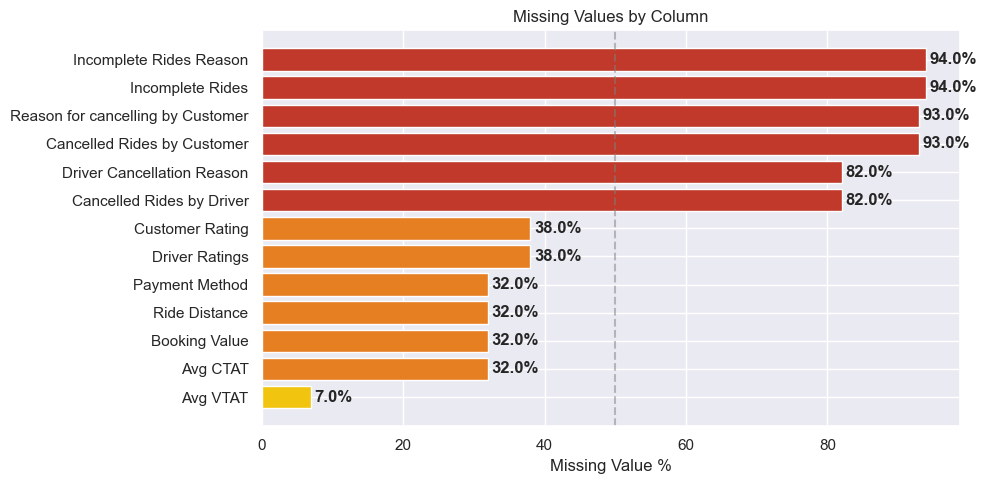

In [52]:
import matplotlib.pyplot as plt
missing_pct = df.isnull().mean() * 100

missing_pct = missing_pct[missing_pct > 0].sort_values()

colors = ['#C0392B' if v > 50 else '#E67E22' if v > 20 else '#F1C40F'
          for v in missing_pct]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors)

for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

ax.axvline(50, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Missing Value %')
ax.set_title('Missing Values by Column')

plt.tight_layout()
plt.show()

In [67]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [68]:
df['Vehicle Type'].value_counts()	

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [53]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate Booking IDs:", df["Booking ID"].duplicated().sum())

print("Unique Booking IDs:", df["Booking ID"].nunique())

Duplicate rows: 0
Duplicate Booking IDs: 1233
Unique Booking IDs: 148767


In [54]:
# IQR function
def outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outlier_indices = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))].index
    return outlier_indices

outlier_indices = outliers (df, 'Avg VTAT')
# convert to dataframe
outlier_indices = pd.DataFrame(outlier_indices)
outlier_indices

,0


In [55]:
df['Date']      = pd.to_datetime(df['Date'])
df['Hour']      = df['Time'].str[:2].astype(int)
df['MonthNum']  = df['Date'].dt.month
df['Month']     = df['Date'].dt.month_name()
df['Day']       = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['DayNum']    = df['Date'].dt.dayofweek

# دمج eBike و Bike
df['VehicleGroup'] = df['Vehicle Type'].replace({'eBike':'eBike/Bike', 'Bike':'eBike/Bike'})

# تصفية الرحلات المكتملة
completed = df[df['Booking Status'] == 'Completed']

# طباعة الملخص
print(f"Date range      : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Completed rows  : {len(completed):,}")
print(f"Vehicle groups  : {df['VehicleGroup'].unique()}")

Date range      : 2024-01-01 to 2024-12-30
Completed rows  : 93,000
Vehicle groups  : ['eBike/Bike' 'Go Sedan' 'Auto' 'Premier Sedan' 'Go Mini' 'Uber XL']


# Visualization

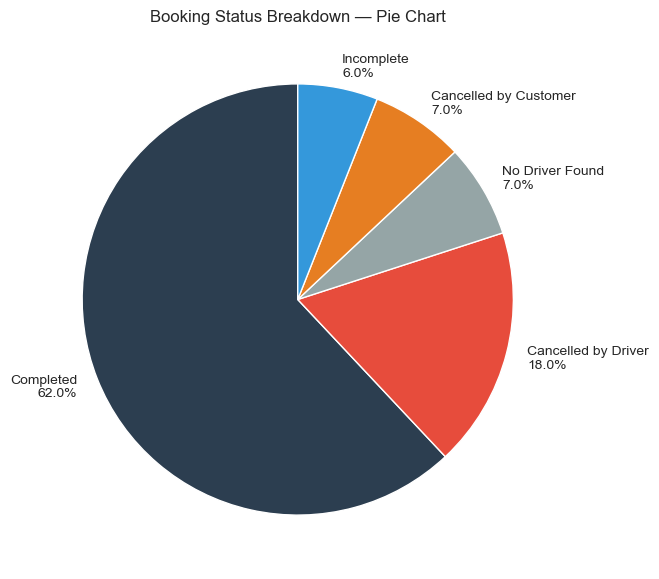

In [56]:
import matplotlib.pyplot as plt
status_pct = df['Booking Status'].value_counts(normalize=True) * 100
STATUS_PALETTE = {
    'Completed'            : '#2C3E50',
    'Cancelled by Driver'  : '#E74C3C',
    'Cancelled by Customer': '#E67E22',
    'No Driver Found'      : '#95A5A6',
    'Incomplete'           : '#3498DB',
}
colors = [STATUS_PALETTE[s] for s in status_pct.index]
plt.figure(figsize=(7,7))
plt.pie(
    status_pct.values,
    labels=[f'{s}\n{v:.1f}%' for s, v in zip(status_pct.index, status_pct.values)],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':1},
    textprops={'fontsize':10}
)
plt.title('Booking Status Breakdown — Pie Chart')
plt.show()

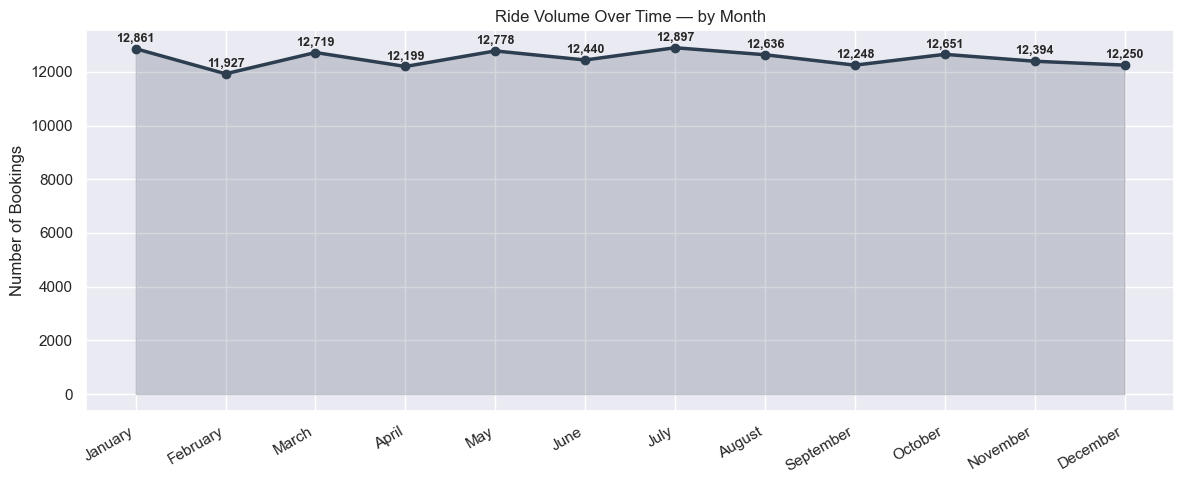

In [57]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['Month'] = df['Date'].dt.month_name()

monthly = df.groupby('Month')['Booking ID'].count().reindex(month_order).fillna(0)

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker='o', color='#2C3E50', lw=2.5)
plt.fill_between(monthly.index, monthly.values, color='#2C3E50', alpha=0.2)

for i, val in enumerate(monthly.values):
    plt.text(i, val + max(monthly.values)*0.02, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.title('Ride Volume Over Time — by Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

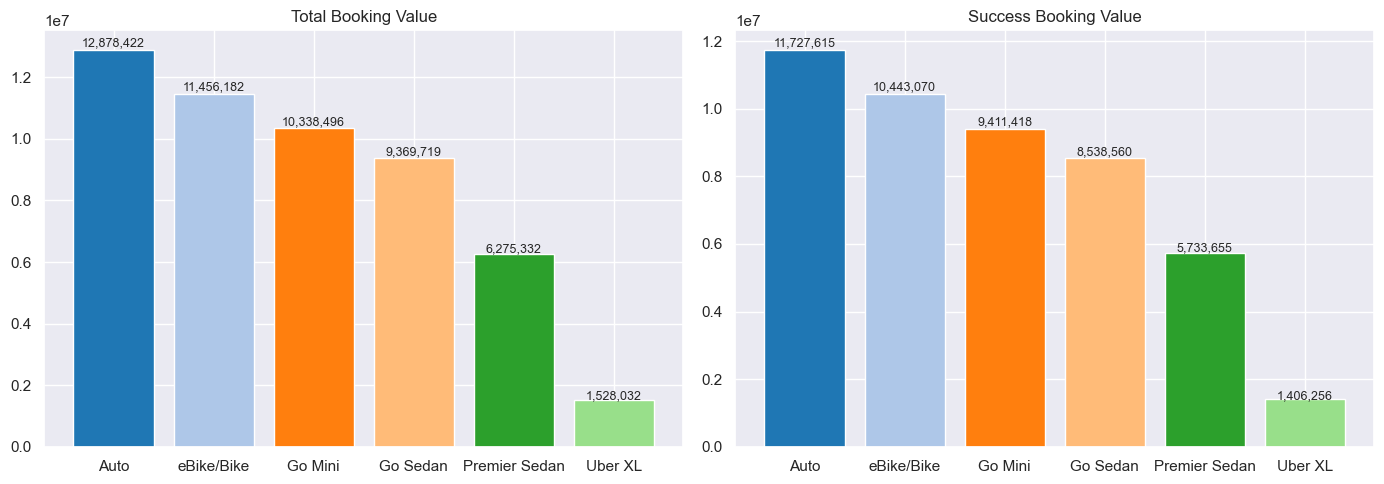

In [58]:
# أولًا، تأكد من وجود VehicleGroup
df['VehicleGroup'] = df['Vehicle Type'].replace({'eBike':'eBike/Bike','Bike':'eBike/Bike'})

# إنشاء جدول KPI حسب VehicleGroup
vehicle_table = df.groupby('VehicleGroup').agg(
    Total_Booking_Value  = ('Booking Value', 'sum'),
    Total_Bookings       = ('Booking ID', 'count'),
    Avg_Distance         = ('Ride Distance', 'mean'),
    Total_Distance       = ('Ride Distance', 'sum'),
).reset_index()

# Success Booking Value (المكتملة فقط)
completed = df[df['Booking Status'] == 'Completed']
success_val = (completed.groupby('VehicleGroup')['Booking Value']
               .sum().reset_index()
               .rename(columns={'Booking Value': 'Success_Booking_Value'}))

vehicle_table = vehicle_table.merge(success_val, on='VehicleGroup', how='left')
vehicle_table['Avg_Distance'] = vehicle_table['Avg_Distance'].round(2)
vehicle_table = vehicle_table.sort_values('Total_Booking_Value', ascending=False)

import matplotlib.pyplot as plt

vehicle_groups = vehicle_table['VehicleGroup']
colors = plt.cm.tab20.colors

fig, axes = plt.subplots(1, 2, figsize=(14,5)) 

# 1️⃣ Total Booking Value
axes[0].bar(vehicle_groups, vehicle_table['Total_Booking_Value'], color=colors[:len(vehicle_groups)])
axes[0].set_title('Total Booking Value')
for i, val in enumerate(vehicle_table['Total_Booking_Value']):
    axes[0].text(i, val*1.01, f'{val:,.0f}', ha='center', fontsize=9)

# 2️⃣ Success Booking Value
axes[1].bar(vehicle_groups, vehicle_table['Success_Booking_Value'], color=colors[:len(vehicle_groups)])
axes[1].set_title('Success Booking Value')
for i, val in enumerate(vehicle_table['Success_Booking_Value']):
    axes[1].text(i, val*1.01, f'{val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

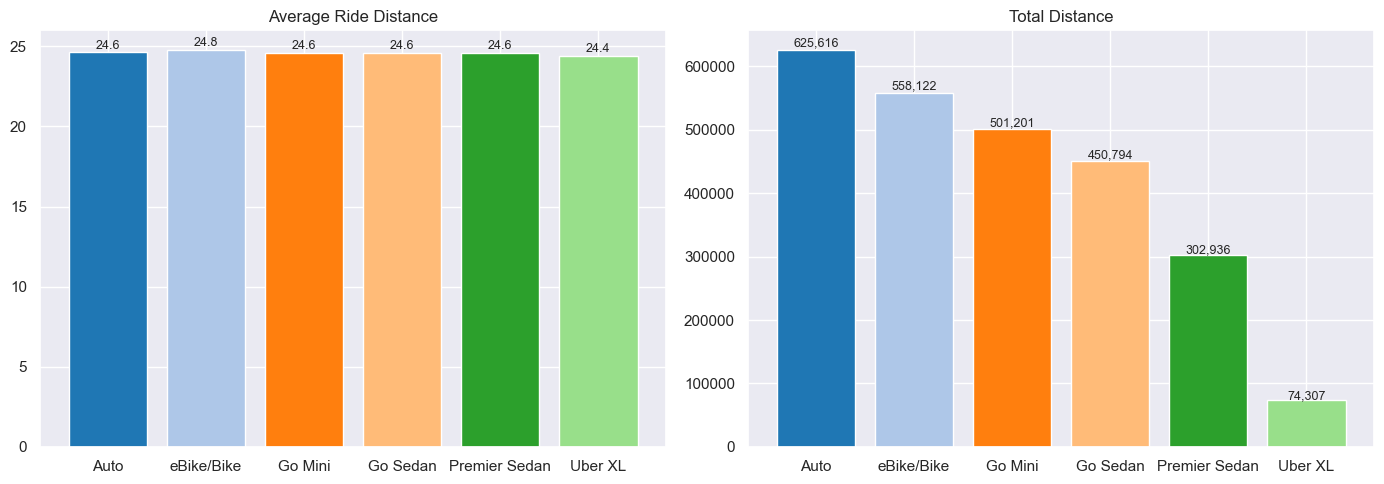

In [59]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 3️⃣ Avg Distance
axes[0].bar(vehicle_groups, vehicle_table['Avg_Distance'], color=colors[:len(vehicle_groups)])
axes[0].set_title('Average Ride Distance')
for i, val in enumerate(vehicle_table['Avg_Distance']):
    axes[0].text(i, val*1.01, f'{val:.1f}', ha='center', fontsize=9)

# 4️⃣ Total Distance
axes[1].bar(vehicle_groups, vehicle_table['Total_Distance'], color=colors[:len(vehicle_groups)])
axes[1].set_title('Total Distance')
for i, val in enumerate(vehicle_table['Total_Distance']):
    axes[1].text(i, val*1.01, f'{val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

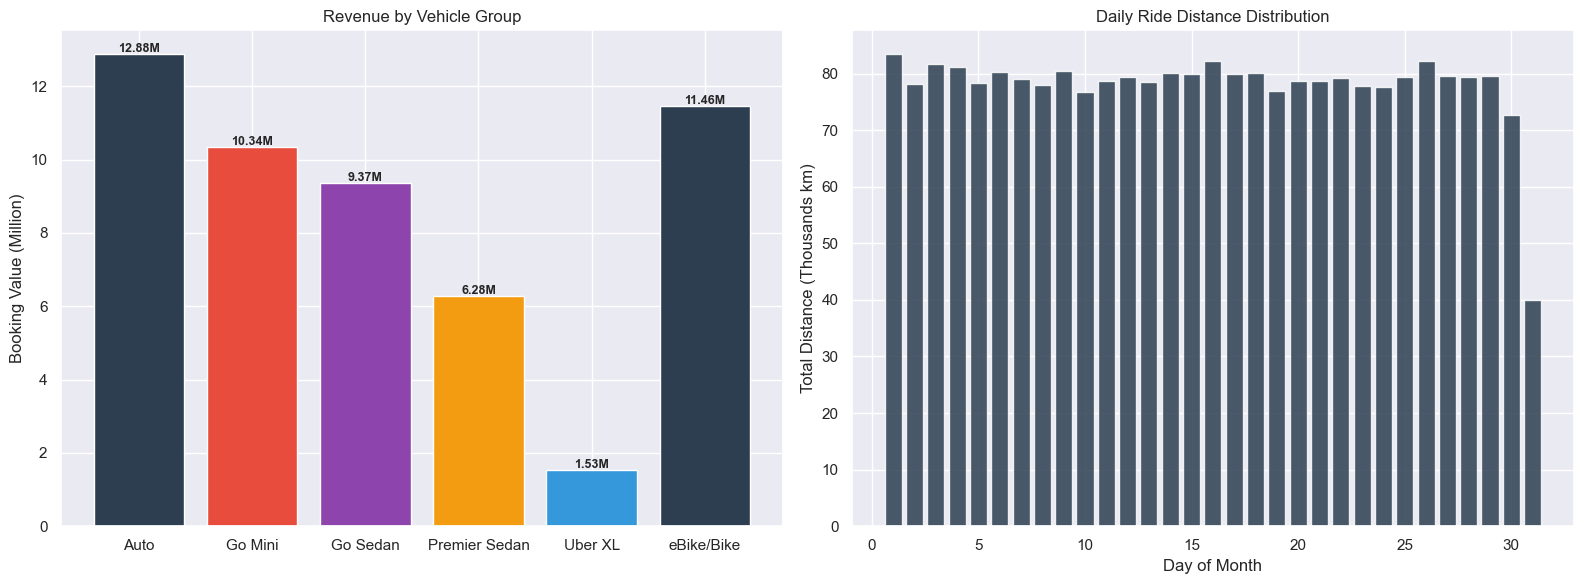

In [60]:
import matplotlib.pyplot as plt

# تأكد انك عندك VehicleGroup
df['VehicleGroup'] = df['Vehicle Type'].replace({'eBike':'eBike/Bike','Bike':'eBike/Bike'})
completed = df[df['Booking Status'] == 'Completed']

# Revenue by VehicleGroup
rev_vehicle = df.groupby('VehicleGroup')['Booking Value'].sum()

# Daily Ride Distance
daily_dist = completed.groupby('Day')['Ride Distance'].sum().reset_index()

# رسم
fig, axes = plt.subplots(1, 2, figsize=(16,6))
pal = ['#2C3E50','#E74C3C','#8E44AD','#F39C12','#3498DB']

# 1️⃣ Revenue by Vehicle
axes[0].bar(rev_vehicle.index, rev_vehicle.values/1e6, color=pal, edgecolor='white')
axes[0].set_title('Revenue by Vehicle Group')
axes[0].set_ylabel('Booking Value (Million)')
for i, v in enumerate(rev_vehicle.values):
    axes[0].text(i, v/1e6 + 0.05, f'{v/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

# 2️⃣ Daily Ride Distance
axes[1].bar(daily_dist['Day'], daily_dist['Ride Distance']/1000, color='#2C3E50', edgecolor='white', alpha=0.85)
axes[1].set_title('Daily Ride Distance Distribution')
axes[1].set_xlabel('Day of Month')
axes[1].set_ylabel('Total Distance (Thousands km)')

plt.tight_layout()
plt.show()

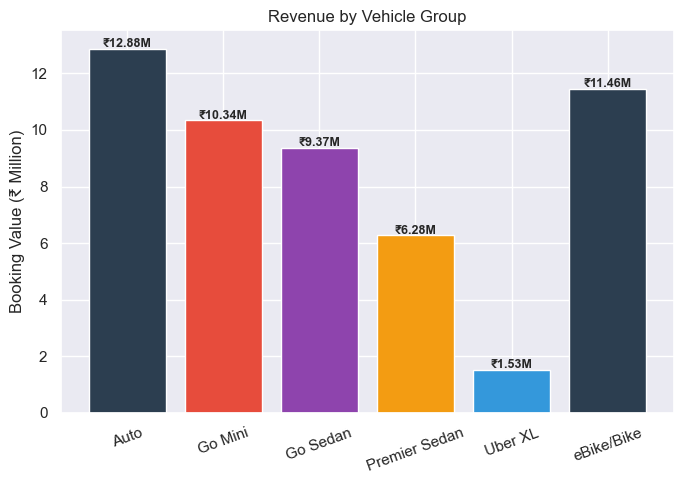

In [61]:
import matplotlib.pyplot as plt

rev_vehicle = df.groupby('VehicleGroup')['Booking Value'].sum()
pal_pay = ['#2C3E50','#E74C3C','#8E44AD','#F39C12','#3498DB']

plt.figure(figsize=(7,5))
plt.bar(rev_vehicle.index, rev_vehicle.values/1e6, color=pal_pay[:len(rev_vehicle)], edgecolor='white')
plt.title('Revenue by Vehicle Group')
plt.ylabel('Booking Value (₹ Million)')
plt.xticks(rotation=20)

# إضافة القيم فوق الأعمدة
for i, v in enumerate(rev_vehicle.values): 
    plt.text(i, v/1e6 + 0.05, f'₹{v/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

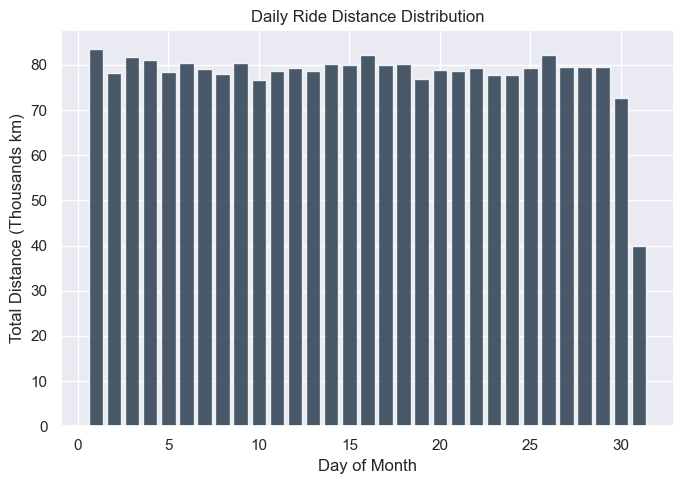

In [62]:
daily_dist = completed.groupby('Day')['Ride Distance'].sum().reset_index()

plt.figure(figsize=(7,5))
plt.bar(daily_dist['Day'], daily_dist['Ride Distance']/1000, color='#2C3E50', edgecolor='white', alpha=0.85)
plt.title('Daily Ride Distance Distribution')
plt.xlabel('Day of Month')
plt.ylabel('Total Distance (Thousands km)')
plt.tight_layout()
plt.show()

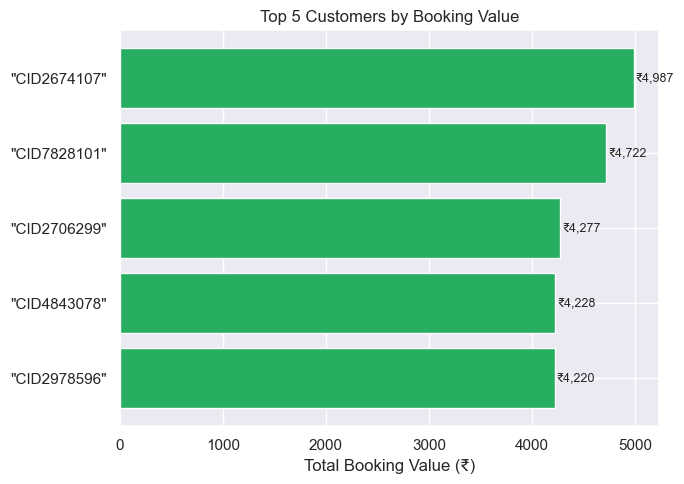

In [63]:
top5 = completed.groupby('Customer ID')['Booking Value'].sum()\
                .sort_values(ascending=False).head(5).reset_index()
top5.columns = ['Customer ID', 'Total Booking Value']

plt.figure(figsize=(7,5))
plt.barh(top5['Customer ID'][::-1], top5['Total Booking Value'][::-1], color='#27AE60', edgecolor='white')
plt.title('Top 5 Customers by Booking Value')
plt.xlabel('Total Booking Value (₹)')

# إضافة القيم على يمين الأعمدة
for i, v in enumerate(top5['Total Booking Value'][::-1]):
    plt.text(v+20, i, f'₹{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

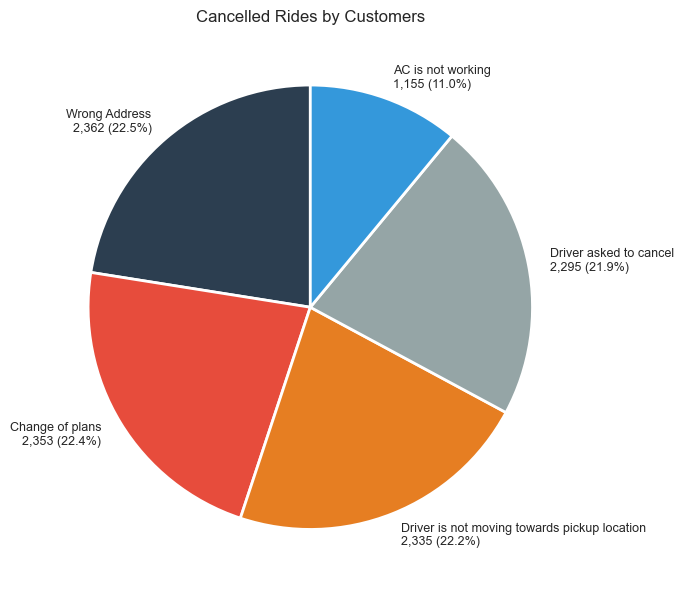

In [64]:

cust_can = df[df['Booking Status'] == 'Cancelled by Customer']
drv_can  = df[df['Booking Status'] == 'Cancelled by Driver']

cc_reasons = cust_can['Reason for cancelling by Customer'].value_counts()
cc_colors = ['#2C3E50','#E74C3C','#E67E22','#95A5A6','#3498DB']

plt.figure(figsize=(7,7))
plt.pie(
    cc_reasons.values,
    labels=[f'{r}\n{v:,} ({v/cc_reasons.sum()*100:.1f}%)'
            for r, v in zip(cc_reasons.index, cc_reasons.values)],
    colors=cc_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize': 9}
)
plt.title('Cancelled Rides by Customers', fontsize=12)
plt.tight_layout()
plt.show()

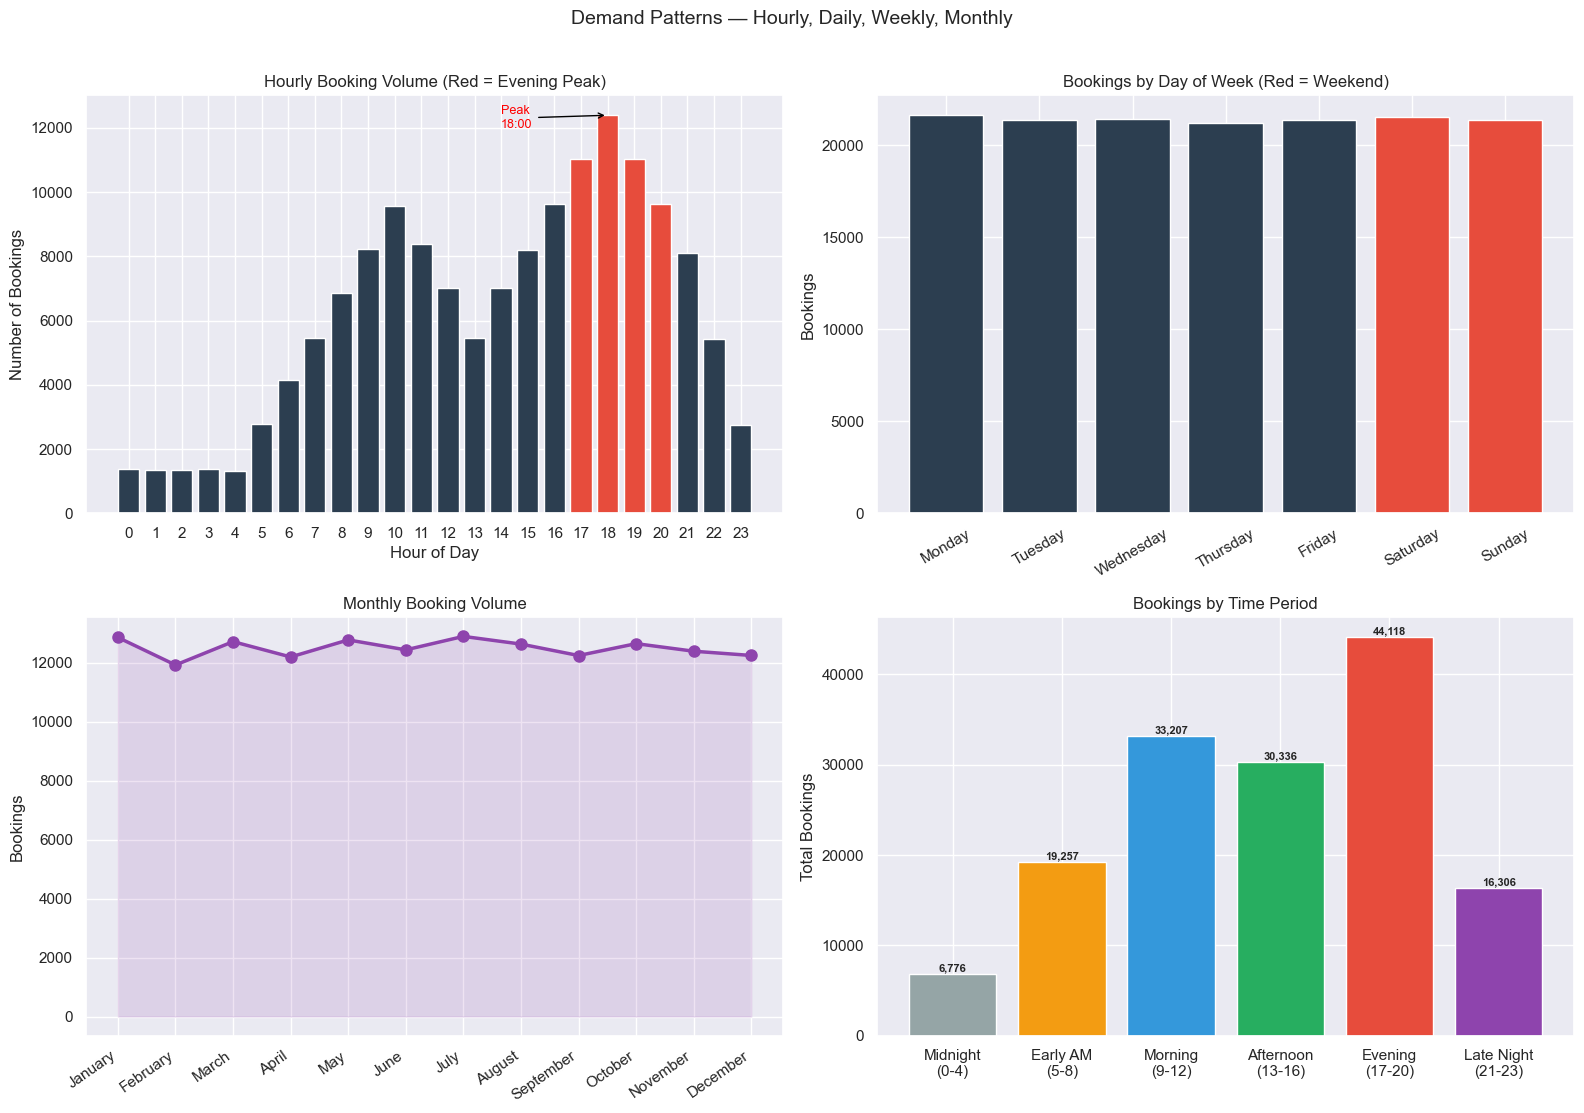

In [65]:
hourly = df.groupby('Hour')['Booking ID'].count()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek')['Booking ID'].count().reindex(day_order)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Hourly demand
peak_cols = ['#E74C3C' if h in [17,18,19,20] else '#2C3E50' for h in hourly.index]
axes[0,0].bar(hourly.index, hourly.values, color=peak_cols, edgecolor='white')
axes[0,0].set_title('Hourly Booking Volume (Red = Evening Peak)')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Number of Bookings')
axes[0,0].set_xticks(range(0,24))
axes[0,0].annotate('Peak\n18:00', xy=(18,12397), xytext=(14,12000),
                   arrowprops=dict(arrowstyle='->', color='black'), fontsize=9, color='red')

# Day of week
dow_cols = ['#E74C3C' if d in ['Saturday','Sunday'] else '#2C3E50' for d in day_order]
axes[0,1].bar(dow.index, dow.values, color=dow_cols, edgecolor='white')
axes[0,1].set_title('Bookings by Day of Week (Red = Weekend)')
axes[0,1].set_ylabel('Bookings')
axes[0,1].tick_params(axis='x', rotation=30)

# Monthly (for comparison — same as dashboard)
monthly = df.groupby(['MonthNum','Month'])['Booking ID'].count().reset_index().sort_values('MonthNum')
axes[1,0].plot(range(len(monthly)), monthly['Booking ID'],
               marker='o', color='#8E44AD', lw=2.5, markersize=8)
axes[1,0].fill_between(range(len(monthly)), monthly['Booking ID'], alpha=0.15, color='#8E44AD')
axes[1,0].set_xticks(range(len(monthly)))
axes[1,0].set_xticklabels(monthly['Month'], rotation=35, ha='right')
axes[1,0].set_title('Monthly Booking Volume')
axes[1,0].set_ylabel('Bookings')

# Time period breakdown
period_labels = ['Midnight\n(0-4)','Early AM\n(5-8)','Morning\n(9-12)',
                 'Afternoon\n(13-16)','Evening\n(17-20)','Late Night\n(21-23)']
period_vals   = [6776, 19257, 33207, 30336, 44118, 16306]
period_cols   = ['#95A5A6','#F39C12','#3498DB','#27AE60','#E74C3C','#8E44AD']
axes[1,1].bar(period_labels, period_vals, color=period_cols, edgecolor='white')
axes[1,1].set_title('Bookings by Time Period')
axes[1,1].set_ylabel('Total Bookings')
for i, v in enumerate(period_vals):
    axes[1,1].text(i, v+300, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Demand Patterns — Hourly, Daily, Weekly, Monthly', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [66]:
df.to_csv(r"C:\Users\JANA MOSTAFA\Downloads\Ride_Bookings\Ride_Bookings\ncr_ride_bookings.csv", index=False)

print("File saved: cleaned_dataset.csv")

File saved: cleaned_dataset.csv
